In [1]:
import joblib
import re

import shap
import lightgbm as lgb
import numpy as np
import pandas as pd

from scipy.stats import skew
from scipy.cluster.hierarchy import linkage

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import ipywidgets as widgets
#widgets.IntSlider()

In [3]:
# Import the features

df_feat=pd.read_csv('../project_eeg/data/features/mean_power_by_epochs_granular.csv')
df_feat.head()

,subject_name,epoch,"CL1_(-4, 0)_alpha","CL1_(-4, 0)_beta","CL1_(-4, 0)_delta","CL1_(-4, 0)_lower gamma","CL1_(-4, 0)_theta","CL1_(0, 5)_alpha","CL1_(0, 5)_beta","CL1_(0, 5)_delta",...,"CL6_(0, 5)_alpha","CL6_(0, 5)_beta","CL6_(0, 5)_delta","CL6_(0, 5)_lower gamma","CL6_(0, 5)_theta","CL6_(5, 10)_alpha","CL6_(5, 10)_beta","CL6_(5, 10)_delta","CL6_(5, 10)_lower gamma","CL6_(5, 10)_theta"
0,P101,1,9.088822e-10,2.072042e-10,3.287845e-09,7.816580e-11,1.656143e-09,1.303344e-09,2.988884e-10,5.732215e-09,...,1.537287e-09,3.561905e-10,4.908325e-09,6.962249e-11,1.729118e-09,1.202900e-09,3.501433e-10,5.478580e-09,5.951559e-11,1.423738e-09
1,P101,2,1.102854e-09,3.646768e-10,2.983556e-09,7.874124e-11,3.031881e-09,8.755720e-10,2.857535e-10,6.854427e-09,...,1.211884e-09,3.354284e-10,5.194283e-09,6.609093e-11,1.488689e-09,9.004423e-10,3.843510e-10,7.098802e-09,6.475551e-11,1.285826e-09
2,P101,3,1.119688e-09,3.283326e-10,5.693652e-09,6.170610e-11,1.940697e-09,1.635918e-09,3.778830e-10,6.764768e-09,...,1.663328e-09,4.766676e-10,4.582519e-09,6.637577e-11,1.316288e-09,1.119152e-09,3.557124e-10,2.524196e-09,5.997453e-11,1.505792e-09
3,P101,4,9.187232e-10,3.496927e-10,4.107768e-09,4.979888e-11,2.149611e-09,1.053823e-09,3.169192e-10,6.734609e-09,...,1.236335e-09,4.668531e-10,3.786341e-09,7.868001e-11,1.832124e-09,1.673658e-09,3.526146e-10,4.241283e-09,6.952896e-11,1.686248e-09
4,P101,5,1.066661e-09,3.380379e-10,2.458196e-09,5.411932e-11,1.880168e-09,1.419091e-09,3.662775e-10,6.364504e-09,...,1.190958e-09,4.125246e-10,5.845627e-09,8.286195e-11,1.713941e-09,9.169432e-10,3.606095e-10,4.427134e-09,7.090293e-11,1.798759e-09


In [4]:
df_target = pd.read_csv('../project_eeg/data/target.csv')
df_target['subject_name']=['P10'+str(x) if len(str(x))<=1 else 'P1'+str(x) for x in df_target.Participant]
df_target = df_target.drop(columns=['Unnamed: 0', 'Participant'])
df_target['epoch']=df_target.groupby(by='subject_name').cumcount()+1

df_target.head()

,PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity,subject_name,epoch
0,H,6,6,6,5,6,P101,1
1,H,6,6,6,5,5,P101,2
2,H,6,6,6,5,6,P101,3
3,H,6,6,5,6,6,P101,4
4,H,6,6,5,4,5,P101,5


In [5]:
df=pd.merge(df_feat,df_target,how='left',on=['subject_name','epoch'])
df.head()

,subject_name,epoch,"CL1_(-4, 0)_alpha","CL1_(-4, 0)_beta","CL1_(-4, 0)_delta","CL1_(-4, 0)_lower gamma","CL1_(-4, 0)_theta","CL1_(0, 5)_alpha","CL1_(0, 5)_beta","CL1_(0, 5)_delta",...,"CL6_(5, 10)_beta","CL6_(5, 10)_delta","CL6_(5, 10)_lower gamma","CL6_(5, 10)_theta",PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity
0,P101,1,9.088822e-10,2.072042e-10,3.287845e-09,7.816580e-11,1.656143e-09,1.303344e-09,2.988884e-10,5.732215e-09,...,3.501433e-10,5.478580e-09,5.951559e-11,1.423738e-09,H,6,6,6,5,6
1,P101,2,1.102854e-09,3.646768e-10,2.983556e-09,7.874124e-11,3.031881e-09,8.755720e-10,2.857535e-10,6.854427e-09,...,3.843510e-10,7.098802e-09,6.475551e-11,1.285826e-09,H,6,6,6,5,5
2,P101,3,1.119688e-09,3.283326e-10,5.693652e-09,6.170610e-11,1.940697e-09,1.635918e-09,3.778830e-10,6.764768e-09,...,3.557124e-10,2.524196e-09,5.997453e-11,1.505792e-09,H,6,6,6,5,6
3,P101,4,9.187232e-10,3.496927e-10,4.107768e-09,4.979888e-11,2.149611e-09,1.053823e-09,3.169192e-10,6.734609e-09,...,3.526146e-10,4.241283e-09,6.952896e-11,1.686248e-09,H,6,6,5,6,6
4,P101,5,1.066661e-09,3.380379e-10,2.458196e-09,5.411932e-11,1.880168e-09,1.419091e-09,3.662775e-10,6.364504e-09,...,3.606095e-10,4.427134e-09,7.090293e-11,1.798759e-09,H,6,6,5,4,5


In [6]:
# Exclude 4 subjects with less data
list_to_drop = ['P105','P141','P142','P146']

df_filtered = df[~df.subject_name.isin(list_to_drop)]

In [7]:
## Divide data into different stimuli

df_haiku = df_filtered[df_filtered.PoemType=='H']
df_senryu = df_filtered[df_filtered.PoemType=='S']
df_control = df_filtered[df_filtered.PoemType=='C']

In [8]:
datasets = {
    'haiku': df_haiku,
    'senryu': df_senryu,
    'control': df_control
}

In [9]:
# Keep original score variable as a target
cols_target = ['Aesthetic_Appeal','Vivid_Imagery','Moved', 'Originality', 'Creativity']

for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    # Drop the poem type column
    df_copy = df_copy.drop(columns='PoemType')
    
    # Add df_copy to the dictionary of binary datasets
    datasets[stimulus] = df_copy

In [10]:
# Make X, y, train-test split for each stimulus
split_datasets = {}

for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    X = df_copy.iloc[:,2:-5]
    y = df_copy.iloc[:,-5:]
    
    # Make one target variable out of 5 - to be removed in next iteration
#    y = y.median(axis=1)
    
    for col_target in cols_target:
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y[col_target], test_size=0.2, random_state=42,
                                                           stratify=y[col_target])

        # Clean column names
        X.columns = [re.sub(r'[^\w\s]', '', col) for col in X.columns]
        X_train.columns = [re.sub(r'[^\w\s]', '', col) for col in X_train.columns]
        X_test.columns = [re.sub(r'[^\w\s]', '', col) for col in X_test.columns]
        
        stimulus_target = str(stimulus)+'_'+str(col_target)
    
        split_datasets[stimulus_target] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'X': X,
            'y': y[col_target]
        }

/var/folders/3j/lvxd1xfx1z5c7t3f2k87b_100000gq/T/ipykernel_45881/2351829400.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  skew_values = X_skew_test.apply(lambda x: skew(x.dropna()), axis=0)  # axis=0 applies per column


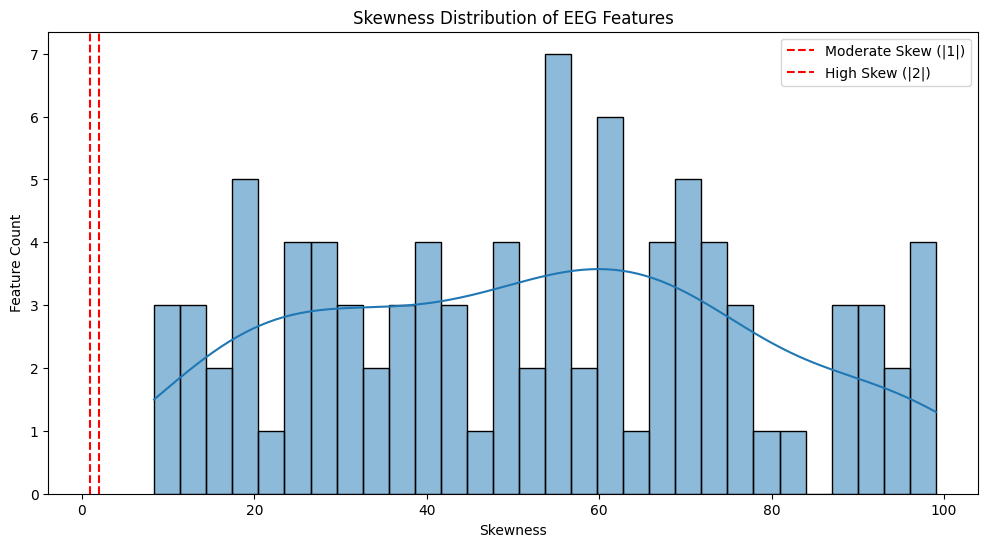

Highly skewed features (|skew| > 1): ['CL1_(-4, 0)_alpha', 'CL1_(-4, 0)_beta', 'CL1_(-4, 0)_delta', 'CL1_(-4, 0)_lower gamma', 'CL1_(-4, 0)_theta', 'CL1_(0, 5)_alpha', 'CL1_(0, 5)_beta', 'CL1_(0, 5)_delta', 'CL1_(0, 5)_lower gamma', 'CL1_(0, 5)_theta', 'CL1_(5, 10)_alpha', 'CL1_(5, 10)_beta', 'CL1_(5, 10)_delta', 'CL1_(5, 10)_lower gamma', 'CL1_(5, 10)_theta', 'CL2_(-4, 0)_alpha', 'CL2_(-4, 0)_beta', 'CL2_(-4, 0)_delta', 'CL2_(-4, 0)_lower gamma', 'CL2_(-4, 0)_theta', 'CL2_(0, 5)_alpha', 'CL2_(0, 5)_beta', 'CL2_(0, 5)_delta', 'CL2_(0, 5)_lower gamma', 'CL2_(0, 5)_theta', 'CL2_(5, 10)_alpha', 'CL2_(5, 10)_beta', 'CL2_(5, 10)_delta', 'CL2_(5, 10)_lower gamma', 'CL2_(5, 10)_theta', 'CL3_(-4, 0)_alpha', 'CL3_(-4, 0)_beta', 'CL3_(-4, 0)_delta', 'CL3_(-4, 0)_lower gamma', 'CL3_(-4, 0)_theta', 'CL3_(0, 5)_alpha', 'CL3_(0, 5)_beta', 'CL3_(0, 5)_delta', 'CL3_(0, 5)_lower gamma', 'CL3_(0, 5)_theta', 'CL3_(5, 10)_alpha', 'CL3_(5, 10)_beta', 'CL3_(5, 10)_delta', 'CL3_(5, 10)_lower gamma', 'CL3_(5,

In [11]:
# Select numerical features (convert if needed)
X_skew_test = df_filtered.iloc[:, 2:-5]  # Select only feature columns

# Ensure all columns are numeric
X_skew_test = X_skew_test.apply(pd.to_numeric, errors='coerce')

# Compute skewness for numeric columns
skew_values = X_skew_test.apply(lambda x: skew(x.dropna()), axis=0)  # axis=0 applies per column

# Plot skewness distribution
plt.figure(figsize=(12,6))
sns.histplot(skew_values, bins=30, kde=True)
plt.axvline(x=1, color='r', linestyle='dashed', label="Moderate Skew (|1|)")
plt.axvline(x=2, color='r', linestyle='dashed', label="High Skew (|2|)")
plt.legend()
plt.xlabel("Skewness")
plt.ylabel("Feature Count")
plt.title("Skewness Distribution of EEG Features")
plt.show()

# Print highly skewed features
highly_skewed_features = skew_values[abs(skew_values) > 1].index
print(f"Highly skewed features (|skew| > 1): {list(highly_skewed_features)}")

In [12]:
normalised_split_datasets = {}

for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    X = df_copy.iloc[:,2:-5]
    y = df_copy.iloc[:,-5:]
    
    # Make one target variable out of 5 - to be removed in next iteration
    #y = y.median(axis=1)
    
    # Normalise the variables
    transformer = PowerTransformer(method='yeo-johnson')
    X_transformed = transformer.fit_transform(X)
    X_transformed = pd.DataFrame(X_transformed, columns=X.columns)
    
    # Train-test split
    for col_target in cols_target:
        X_train, X_test, y_train, y_test = train_test_split(X_transformed, y[col_target], test_size=0.2,
                                                            random_state=42, stratify=y[col_target])
    
        stimulus_target = str(stimulus)+'_'+str(col_target)
        
        normalised_split_datasets[stimulus_target] = {
            'X': X_transformed,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'X_transformed': X_transformed,
            'y': y[col_target]
        }

In [14]:
def get_hierarchy_feature_names(features):
    cluster = []
    time_period = []
    frequency = []
    for feature in features:
        parts = feature.split('_')  # Split feature into parts
        cluster.append(parts[0])  # CL1, CL2, ...
        time_period.append(parts[1])  # (-4, 0), (0, 5), (5, 10)
        frequency.append(parts[2])  # alpha, beta, delta, lower gamma, theta
    return pd.DataFrame({
        'Cluster': cluster,
        'Time Period': time_period,
        'Frequency': frequency
    }, index=features)

In [16]:
shap_export = pd.DataFrame(columns = ['Stimulus', 'TargetScore', 'features', 'SHAP_value', 'Cluster',
       'Time Period', 'Frequency'])

## Make a loop to run through model objects and get SHAP values

for stimulus_target, df in normalised_split_datasets.items():

    model_path_and_name = f"models/lightgbm_model_{stimulus_target}.joblib"
    lgbm_model = joblib.load(model_path_and_name)

    explainer = shap.TreeExplainer(lgbm_model)
    shap_values = explainer.shap_values(normalised_split_datasets[stimulus_target]['X'])
    shap_values_sum = np.sum(shap_values, axis=2)
    
    shap_values_sum_df = pd.DataFrame(shap_values_sum, columns=X.columns)
    shap_values_sum_df['Stimulus'] = stimulus_target.split("_")[0].capitalize()
    str_target = stimulus_target.split("_")[1:]
    shap_values_sum_df['TargetScore'] = f"{'_'.join(str_target)}"

    shap_melted = shap_values_sum_df.melt(id_vars=shap_values_sum_df.columns[-2:], var_name='features', value_name='SHAP_value')
    shap_df_to_export = pd.merge(shap_melted,hierarchical_features,left_on='features', right_index=True) 
    
    shap_export = pd.concat([shap_export, shap_df_to_export], ignore_index=True)

/Users/Daria.Meshcherina/shap_env/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.1.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/folders/3j/lvxd1xfx1z5c7t3f2k87b_100000gq/T/ipykernel_45881/90092556.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shap_export = pd.concat([shap_export, shap_df_to_export], ignore_index=True)
/Users/Daria.Meshcherina/shap_env/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle e

In [17]:
shap_export.to_csv('shap_values_lightgbm.csv', index=False)

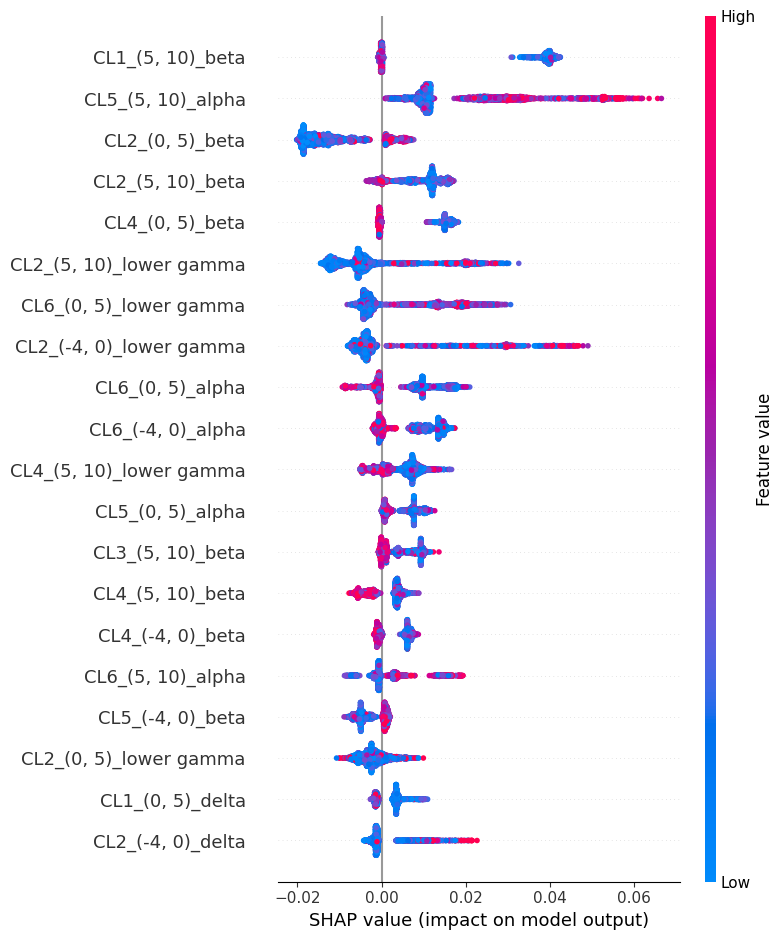

In [18]:
#Shows feature importance and direction of impact.

#🔹 Interpretation:
#	•	Features at the top are most influential.
#	•	Colors: Red (higher values), Blue (lower values).
#	•	X-axis: Positive or negative contribution to predictions.

shap.summary_plot(shap_values_sum, normalised_split_datasets['haiku_Aesthetic_Appeal']['X'])

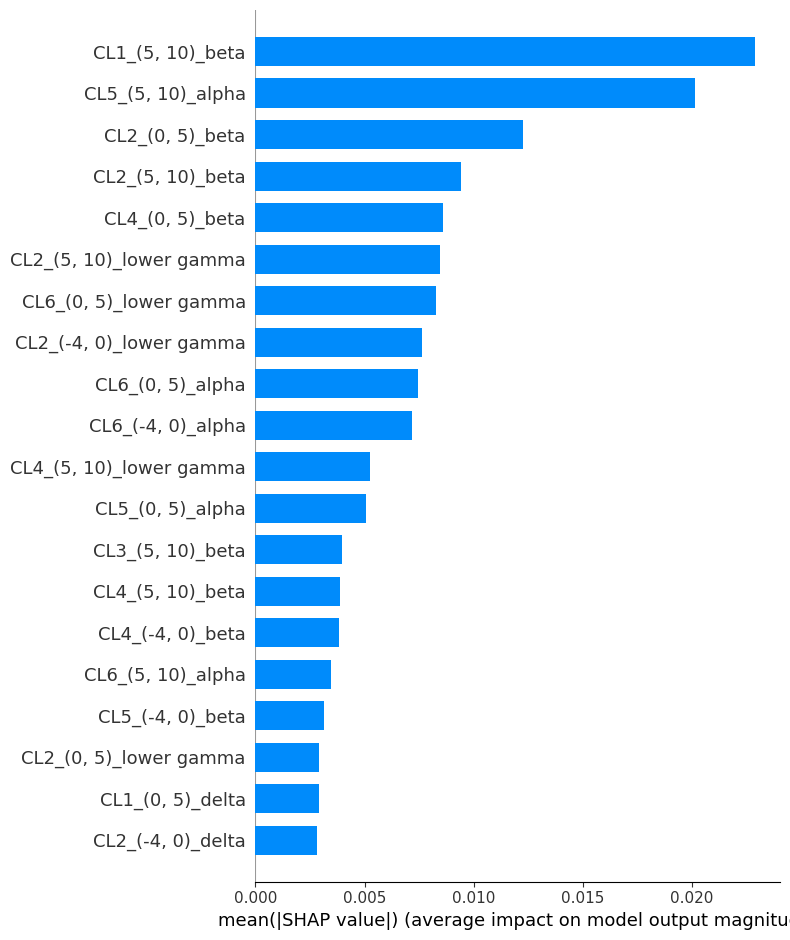

In [19]:
#Shows average absolute SHAP values, ranking features by importance.
#🔹 Interpretation:
#	•	Higher bars = More influential features.

shap.summary_plot(shap_values_sum, normalised_split_datasets['haiku_Aesthetic_Appeal']['X'], plot_type="bar")

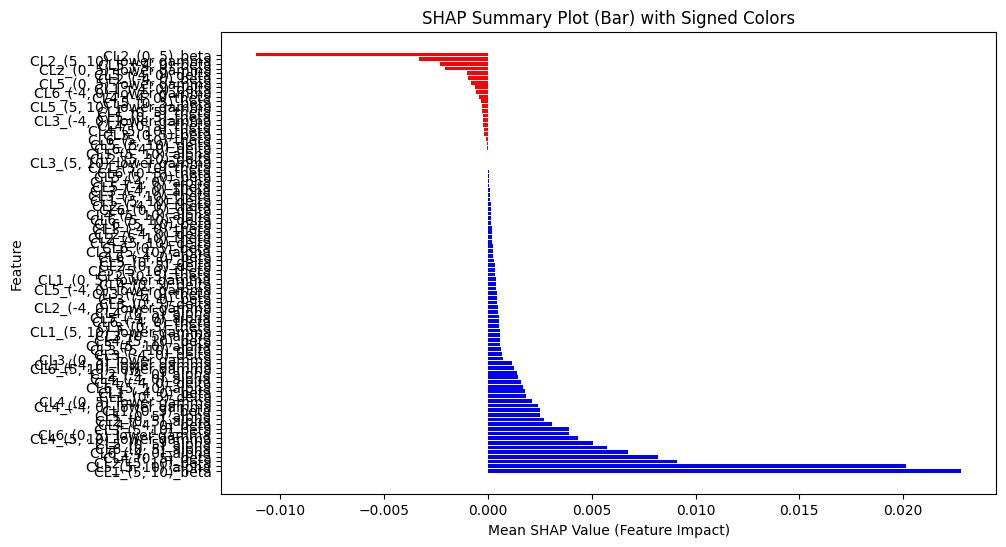

In [20]:
# Compute mean SHAP values and their sign
shap_means = np.mean(shap_values_sum, axis=0)
signs = np.sign(shap_means)  # +1 for positive effects, -1 for negative

# Assign colors based on sign: red (negative) & blue (positive)
colors = np.array(["red" if s < 0 else "blue" for s in signs])

# Create bar plot with colors
plt.figure(figsize=(10, 6))
plt.barh(
    np.array(normalised_split_datasets['haiku_Aesthetic_Appeal']['X'].columns)[np.argsort(shap_means)], 
    np.sort(shap_means), 
    color=colors[np.argsort(shap_means)]
)
plt.xlabel("Mean SHAP Value (Feature Impact)")
plt.ylabel("Feature")
plt.title("SHAP Summary Plot (Bar) with Signed Colors")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

/var/folders/3j/lvxd1xfx1z5c7t3f2k87b_100000gq/T/ipykernel_45881/3771055022.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=filtered_shap_values, y=filtered_features, palette=colors)


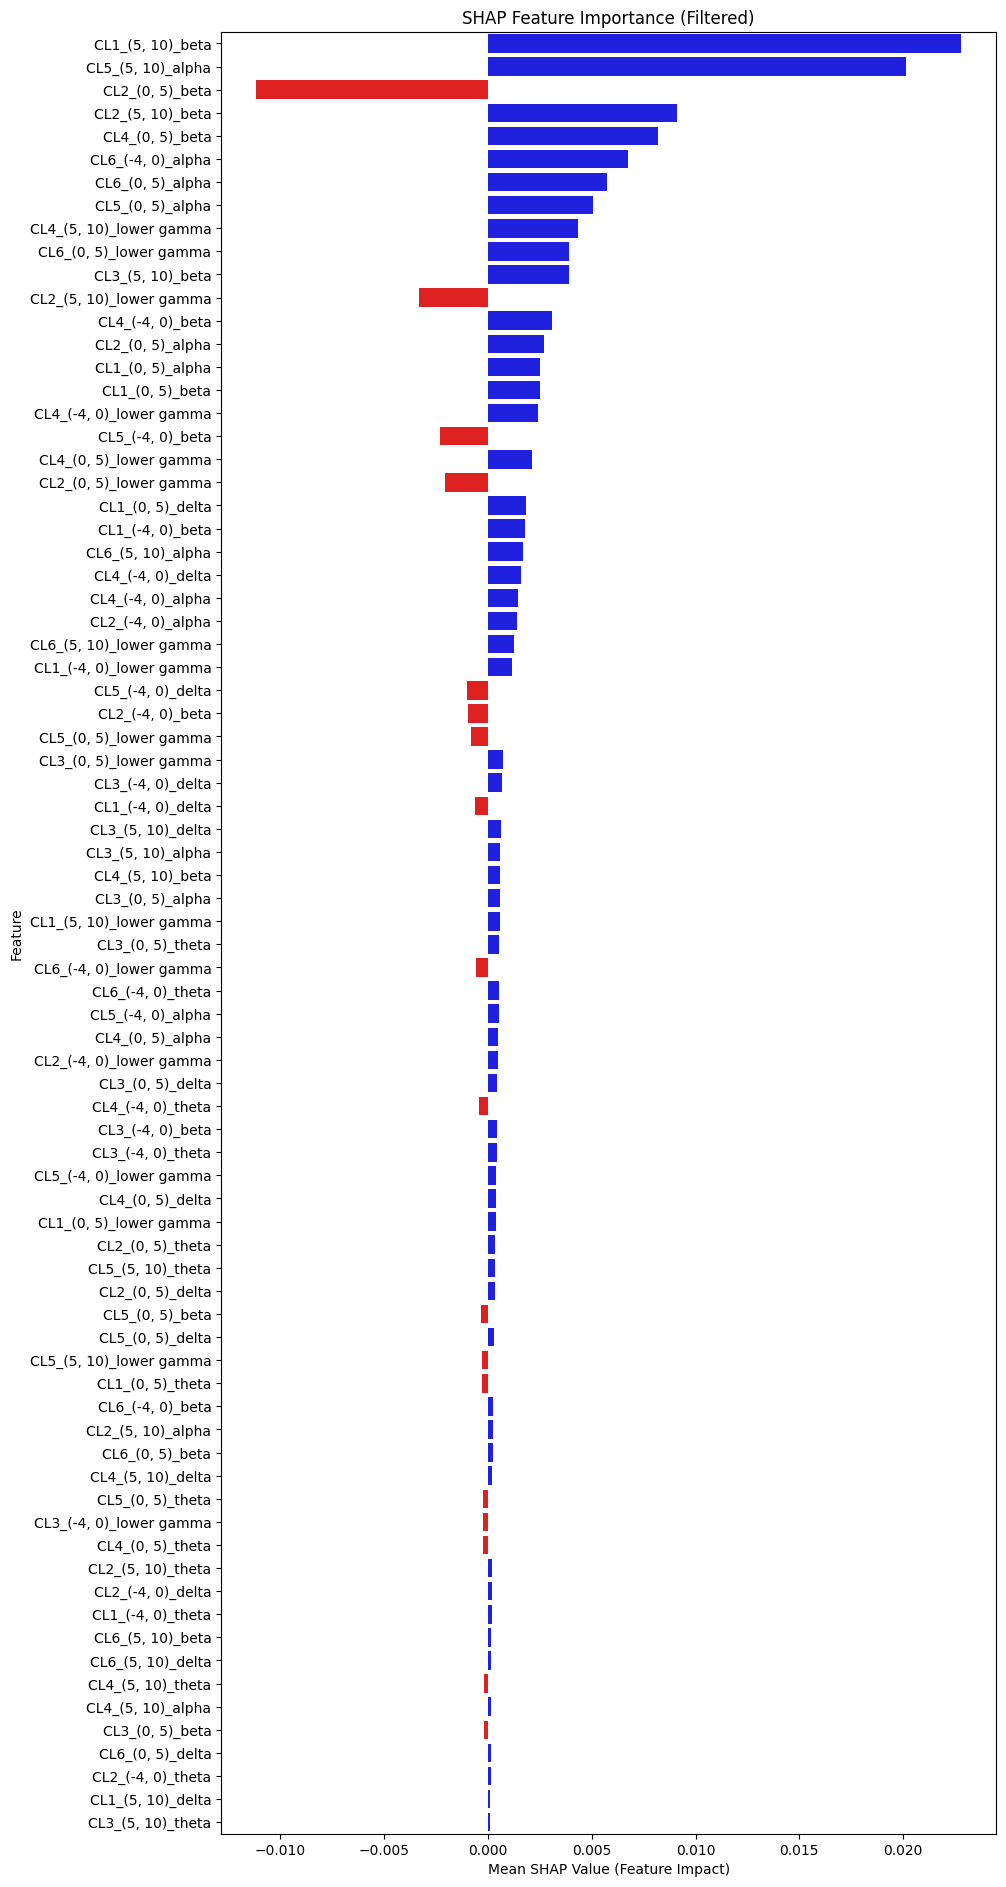

In [21]:
# Get feature names
feature_names = np.array(normalised_split_datasets['haiku_Aesthetic_Appeal']['X'].columns)

# Set a threshold for filtering (adjust as needed)
threshold = 0.0001  # Ignore features with very small importance

# Filter features based on absolute SHAP value
mask = np.abs(shap_means) > threshold
filtered_features = feature_names[mask]
filtered_shap_values = shap_means[mask]

# Sort remaining features by absolute mean SHAP value (descending)
sorted_indices = np.argsort(np.abs(filtered_shap_values))[::-1]
filtered_features = filtered_features[sorted_indices]
filtered_shap_values = filtered_shap_values[sorted_indices]

# Assign colors based on SHAP sign (positive=blue, negative=red)
colors = ["blue" if s > 0 else "red" for s in filtered_shap_values]

# Create Seaborn barplot
plt.figure(figsize=(10, max(6, len(filtered_features) * 0.3)))  # Adjust height dynamically
sns.barplot(x=filtered_shap_values, y=filtered_features, palette=colors)

# Labels and title
plt.xlabel("Mean SHAP Value (Feature Impact)")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance (Filtered)")

# Show plot
plt.show()

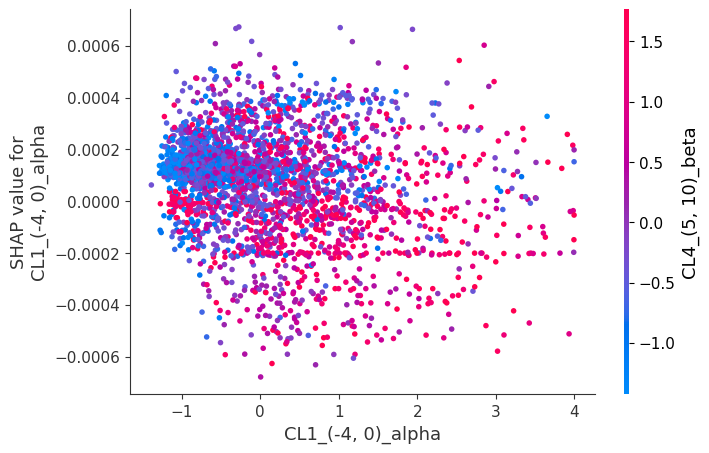

In [22]:
#Shows how a specific feature affects predictions.
#🔹 Interpretation:
#	•	X-axis: Feature value.
#	•	Y-axis: SHAP value (impact on prediction).
#	•	Color: Interaction with another feature.

shap.dependence_plot("CL1_(-4, 0)_alpha", shap_values_sum, normalised_split_datasets['haiku_Aesthetic_Appeal']['X'])

In [23]:
#Shows individual predictions.
#🔹 Interpretation:
#	•	Arrows indicate whether a feature increases or decreases the prediction.

shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values_sum[0], normalised_split_datasets['haiku_Aesthetic_Appeal']['X'].iloc[0, :])

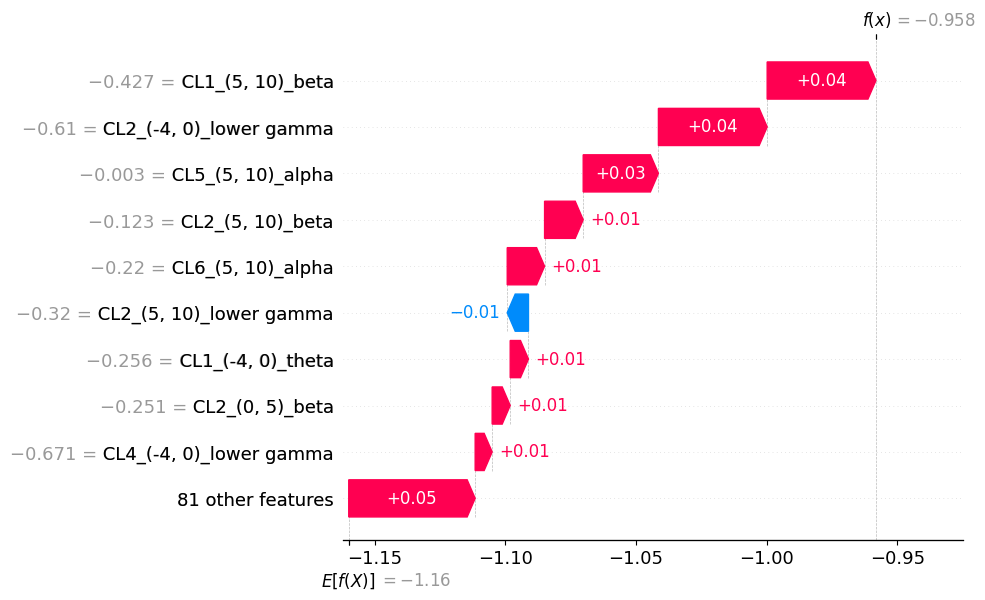

In [24]:
#Shows how each feature contributes to the final prediction
#🔹 Interpretation:
#	•	Shows how each feature contributes to the final prediction.

shap.waterfall_plot(shap.Explanation(values=shap_values_sum[0], 
                                     base_values=explainer.expected_value[0], 
                                     data=normalised_split_datasets['haiku_Aesthetic_Appeal']['X'].iloc[0]))

<Figure size 1200x800 with 0 Axes>

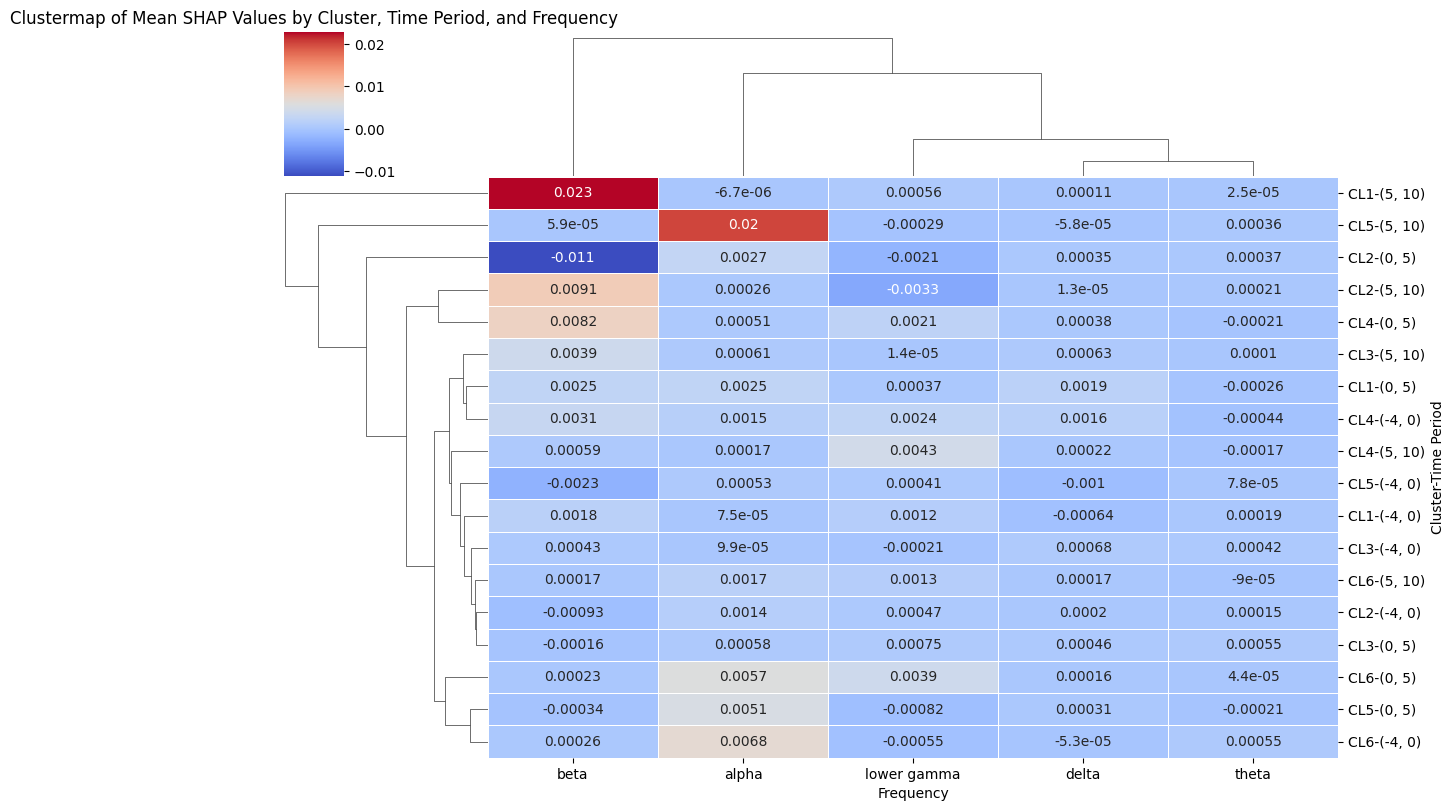

In [25]:
# Reshape the feature names into a hierarchical structure
# Extracting feature information (Cluster, Time Period, Frequency)
def get_hierarchy_feature_names(features):
    cluster = []
    time_period = []
    frequency = []
    for feature in features:
        parts = feature.split('_')  # Split feature into parts
        cluster.append(parts[0])  # CL1, CL2, ...
        time_period.append(parts[1])  # (-4, 0), (0, 5), (5, 10)
        frequency.append(parts[2])  # alpha, beta, delta, lower gamma, theta
    return pd.DataFrame({
        'Cluster': cluster,
        'Time Period': time_period,
        'Frequency': frequency
    }, index=features)

# Get the hierarchical feature names
hierarchical_features = get_hierarchy_feature_names(normalised_split_datasets['haiku_Aesthetic_Appeal']['X'].columns)

# Create a DataFrame of the mean SHAP values and their corresponding features
mean_shap_df = pd.DataFrame(shap_means, columns=['Mean SHAP'], index=normalised_split_datasets['haiku_Aesthetic_Appeal']['X'].columns)

# Create a pivot table to reorganize the data for the heatmap (this will allow clustering by levels)
pivot_data = pd.merge(mean_shap_df.reset_index(),hierarchical_features.reset_index(),left_on='index',right_on='index')
pivot_data_normalised = pivot_data.pivot_table(index=['Cluster', 'Time Period'], columns='Frequency', values='Mean SHAP')

# Optional: You can normalize the data to make it between 0 and 1 for better visual effect
#scaler = PowerTransformer()
#pivot_data_normalized = pd.DataFrame(scaler.fit_transform(pivot_data), columns=pivot_data.columns, index=pivot_data.index)

# Plot the clustermap
plt.figure(figsize=(12, 8))
sns.clustermap(pivot_data_normalised, annot=True, cmap='coolwarm', figsize=(12, 8), linewidths=0.5)
plt.title("Clustermap of Mean SHAP Values by Cluster, Time Period, and Frequency")
plt.show()

<Figure size 1200x800 with 0 Axes>

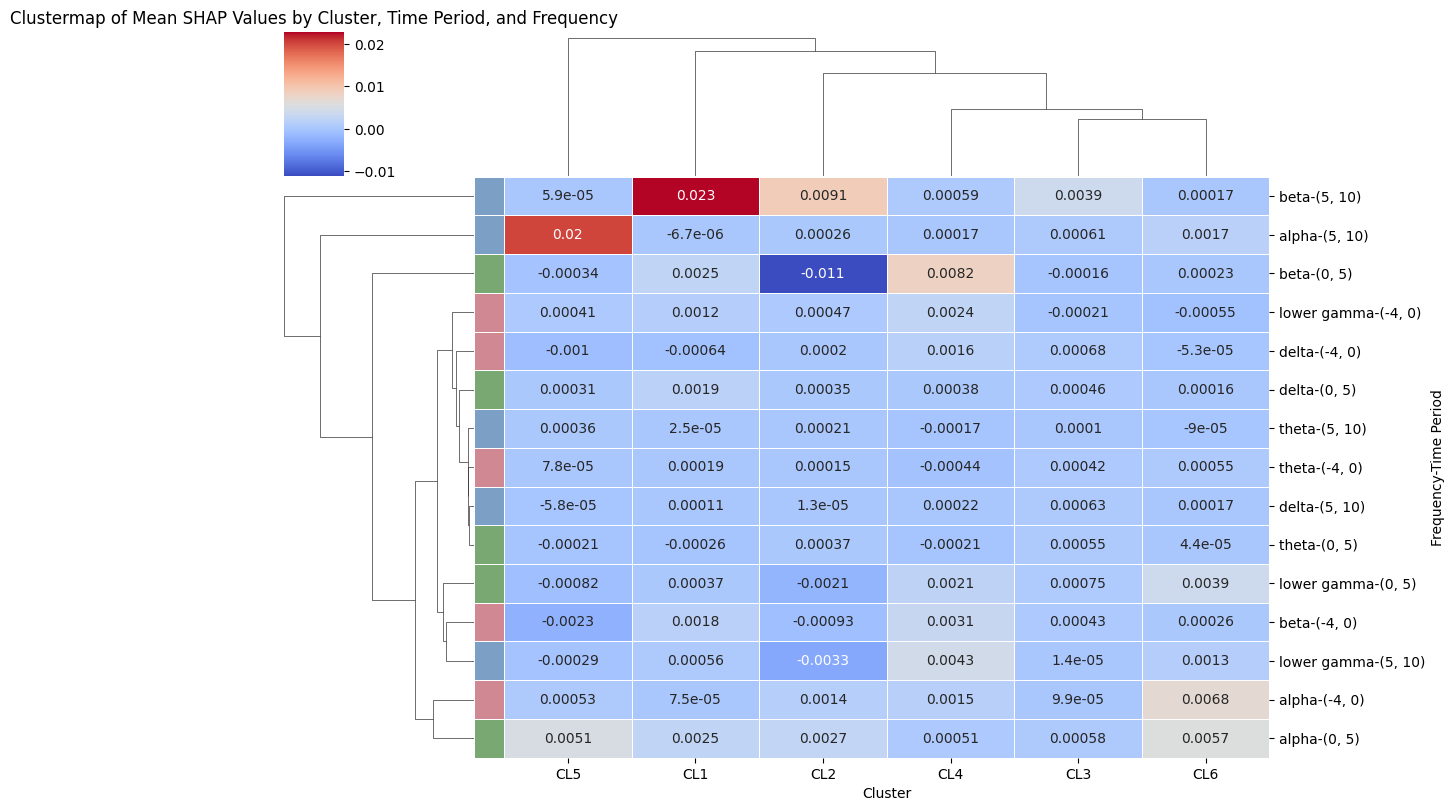

In [26]:
# Reshape the feature names into a hierarchical structure
# Extracting feature information (Cluster, Time Period, Frequency)
def get_hierarchy_feature_names(features):
    cluster = []
    time_period = []
    frequency = []
    for feature in features:
        parts = feature.split('_')  # Split feature into parts
        cluster.append(parts[0])  # CL1, CL2, ...
        time_period.append(parts[1])  # (-4, 0), (0, 5), (5, 10)
        frequency.append(parts[2])  # alpha, beta, delta, lower gamma, theta
    return pd.DataFrame({
        'Cluster': cluster,
        'Time Period': time_period,
        'Frequency': frequency
    }, index=features)

# Get the hierarchical feature names
hierarchical_features = get_hierarchy_feature_names(normalised_split_datasets['haiku_Aesthetic_Appeal']['X'].columns)

# Compute mean SHAP values and their sign
shap_means = np.mean(shap_values_sum, axis=0)
# Create a DataFrame of the mean SHAP values and their corresponding features
mean_shap_df = pd.DataFrame(shap_means, columns=['Mean SHAP'], index=normalised_split_datasets['haiku_Aesthetic_Appeal']['X'].columns)

# Create a pivot table to reorganize the data for the heatmap (this will allow clustering by levels)
pivot_data = pd.merge(mean_shap_df.reset_index(), hierarchical_features.reset_index(), left_on='index', right_on='index')

# Pivoting for the heatmap - this version keeps time period as a separate row or column
pivot_data_normalised = pivot_data.pivot_table(columns=['Cluster'], index=['Frequency','Time Period'], values='Mean SHAP')

# Optional: You can normalize the data to make it between 0 and 1 for better visual effect
#scaler = PowerTransformer()
#pivot_data_normalized = pd.DataFrame(scaler.fit_transform(pivot_data), columns=pivot_data.columns, index=pivot_data.index)

# Plot the clustermap
plt.figure(figsize=(12, 8))

# Create a categorical palette using Seaborn's husl_palette
time_period_pal = sns.husl_palette(3, s=.45)  # Choose 3 distinct colors for 3 time periods
time_period_lut = dict(zip(['(-4, 0)', '(0, 5)', '(5, 10)'], time_period_pal))

# Extract 'Time Period' from the row index (which is a MultiIndex with 'Frequency' and 'Time Period')
row_colors = pivot_data_normalised.index.get_level_values('Time Period').map(time_period_lut)

# Make sure that row_colors are applied correctly to the clustermap
sns.clustermap(pivot_data_normalised, annot=True, cmap='coolwarm', figsize=(12, 8), linewidths=0.5, 
               row_colors=row_colors)

plt.title("Clustermap of Mean SHAP Values by Cluster, Time Period, and Frequency")
plt.show()